# Validação visual — π no pipeline completo (cenário, não só Fonte A isolada)

Notebook de material de revisão, não parte do pipeline de produção.
`validacao_visual_pi_fonte_a.ipynb` (tarefa anterior) validou π isolado
dentro de `ElectionModel.fonte_a_eventos_fronteira`, só classe positiva.
Este notebook valida a integração completa descrita na síntese
consolidada de π em `CLAUDE.md`: (1) as duas classes (positiva/negativa)
degradam de forma comparável sob o mesmo π — a base visual da decisão de
mascarar as duas com o mesmo valor; (2) Fonte B permanece invariante a π
através de `gerar_cenario_adversarial`/`gerar_cenario_normal`, não só
dentro de `model.py` isolado; (3) a interação π×β — mais fragmentação
aumenta a chance de sub-eventos sobreviverem à máscara.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if (Path.cwd() / "src").exists():
    PROJECT_ROOT = Path.cwd()
elif (Path.cwd().parent / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from src.generator.adversarial_mode import gerar_cenario_adversarial
from src.generator.layer1_abm import ElectionModel
from src.generator.normal_mode import contagem_por_timestep, gerar_cenario_normal

plt.rcParams["figure.dpi"] = 100
print(f"Projeto em: {PROJECT_ROOT}")

C:\Users\Dell\Desktop\TCC_Projeto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Projeto em: C:\Users\Dell\Desktop\TCC_Projeto


## 1. Fração observada vs. π, pelas duas classes

Validação mais importante deste notebook. Para cada π, construímos uma
instância NOVA de `ElectionModel` por classe (mesma seed de tudo mais —
`pi` é parâmetro de construtor, mesma razão já documentada no notebook
anterior) e chamamos `gerar_cenario_adversarial`/`gerar_cenario_normal`
com o MESMO `random_state_pi` em todas as chamadas de uma classe, para
que a diferença visual venha só de π. A fração bruta (denominador) da
classe negativa não é exposta diretamente por `gerar_cenario_normal` —
por isso rodamos primeiro com `pi=0.0` para obter o total bruto de cada
classe, e usamos isso como denominador para as demais.

In [2]:
valores_pi = [0.0, 0.5, 0.75, 0.9, 0.95]
RANDOM_STATE_PI = 123

kwargs_positiva = dict(
    recompensa=10.0, threshold_range=(0.0, 0.3), resultado_alvo=0.0, prop_racional=1.0, n_agentes=200
)
kwargs_negativa = dict(recompensa=0.0, n_candidatos=3, n_agentes=200)

fracoes_positiva = {}
fracoes_negativa = {}

for pi in valores_pi:
    modelo_pos = ElectionModel(pi=pi, seed=7, **kwargs_positiva)
    cenario_pos = gerar_cenario_adversarial(modelo_pos, tau_kendall=0.5, random_state_fonte_b=1, random_state_pi=RANDOM_STATE_PI)
    n_bruto_pos = len(modelo_pos.eventos_desembolso)
    fracoes_positiva[pi] = cenario_pos.fonte_a["n_eventos"].sum() / n_bruto_pos

    modelo_neg = ElectionModel(pi=pi, seed=7, **kwargs_negativa)
    cenario_neg = gerar_cenario_normal(
        modelo_neg, janela=50.0, taxa_fonte_a=5.0, volume_medio_fonte_a=1000.0, taxa_fonte_b=1.0,
        random_state_fonte_a=2, random_state_fonte_b=3, random_state_pi=RANDOM_STATE_PI,
    )
    if pi == 0.0:
        n_bruto_neg = cenario_neg.fonte_a["n_eventos"].sum()
    fracoes_negativa[pi] = cenario_neg.fonte_a["n_eventos"].sum() / n_bruto_neg

print(f"n_bruto positiva: {n_bruto_pos}   n_bruto negativa (pi=0.0): {n_bruto_neg}")

n_bruto positiva: 200   n_bruto negativa (pi=0.0): 238


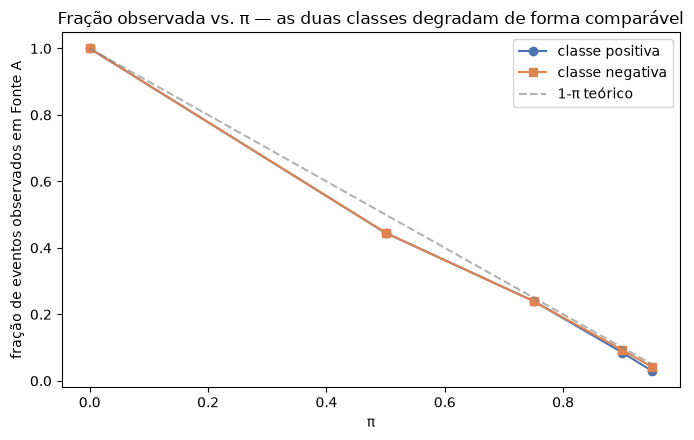

     π    positiva    negativa
  0.00       1.000       1.000
  0.50       0.445       0.445
  0.75       0.240       0.239
  0.90       0.085       0.092
  0.95       0.030       0.042


In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(valores_pi, [fracoes_positiva[pi] for pi in valores_pi], "o-", color="#4C72B0", label="classe positiva")
ax.plot(valores_pi, [fracoes_negativa[pi] for pi in valores_pi], "s-", color="#DD8452", label="classe negativa")
ax.plot(valores_pi, [1 - pi for pi in valores_pi], "--", color="gray", label="1-π teórico", alpha=0.6)

ax.set_xlabel("π")
ax.set_ylabel("fração de eventos observados em Fonte A")
ax.set_title("Fração observada vs. π — as duas classes degradam de forma comparável")
ax.legend()
fig.tight_layout()
plt.show()

print(f"{'π':>6}  {'positiva':>10}  {'negativa':>10}")
for pi in valores_pi:
    print(f"{pi:6.2f}  {fracoes_positiva[pi]:10.3f}  {fracoes_negativa[pi]:10.3f}")

**Leitura:** as duas linhas caem de forma comparável, próximas da
referência teórica `1-π` (tracejada), sem uma classe degradar visivelmente
mais rápido que a outra. É essa comparabilidade que sustenta a decisão
registrada em `CLAUDE.md` de mascarar as duas classes com o mesmo π — se
uma caísse muito mais rápido que a outra, o detector teria um atalho
espúrio de densidade para distinguir as classes, independente do padrão
de coordenação genuíno que a detecção deveria aprender.

## 2. Fonte B invariante a π (positiva e negativa)

Mesmos cenários da Seção 1, mas agora fixando `random_state_fonte_b`
entre as chamadas e variando só π — se a garantia estrutural (π nunca
vaza para Fonte B) vale através do pipeline de cenário completo, Fonte B
deve ficar EXATAMENTE igual entre os valores de π, para as duas classes.

In [4]:
fontes_b_positiva = {}
fontes_b_negativa = {}

for pi in valores_pi:
    modelo_pos = ElectionModel(pi=pi, seed=7, **kwargs_positiva)
    cenario_pos = gerar_cenario_adversarial(modelo_pos, tau_kendall=0.5, random_state_fonte_b=1, random_state_pi=RANDOM_STATE_PI)
    fontes_b_positiva[pi] = cenario_pos.fonte_b

    modelo_neg = ElectionModel(pi=pi, seed=7, **kwargs_negativa)
    cenario_neg = gerar_cenario_normal(
        modelo_neg, janela=50.0, taxa_fonte_a=5.0, volume_medio_fonte_a=1000.0, taxa_fonte_b=1.0,
        random_state_fonte_a=2, random_state_fonte_b=3, random_state_pi=RANDOM_STATE_PI,
    )
    fontes_b_negativa[pi] = cenario_neg.fonte_b

for pi in valores_pi[1:]:
    assert np.array_equal(fontes_b_positiva[0.0], fontes_b_positiva[pi]), f"Fonte B (positiva) mudou em pi={pi}"
    assert np.array_equal(fontes_b_negativa[0.0], fontes_b_negativa[pi]), f"Fonte B (negativa) mudou em pi={pi}"
print("OK: Fonte B idêntica em todos os valores de π, para as duas classes.")

OK: Fonte B idêntica em todos os valores de π, para as duas classes.


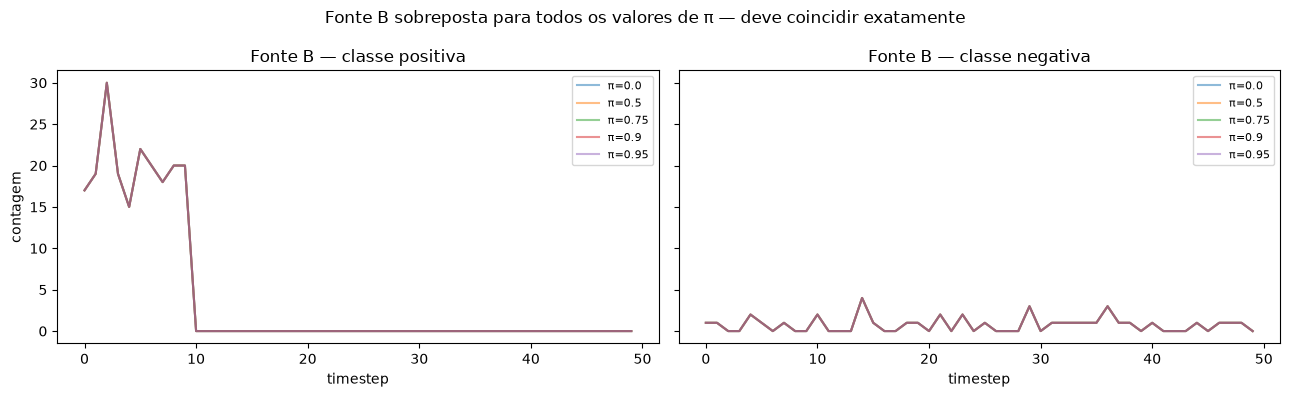

In [5]:
JANELA = 50.0
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for pi in valores_pi:
    axes[0].plot(contagem_por_timestep(fontes_b_positiva[pi], JANELA), alpha=0.5, label=f"π={pi}")
    axes[1].plot(contagem_por_timestep(fontes_b_negativa[pi], JANELA), alpha=0.5, label=f"π={pi}")

axes[0].set_title("Fonte B — classe positiva")
axes[1].set_title("Fonte B — classe negativa")
for ax in axes:
    ax.set_xlabel("timestep")
    ax.legend(fontsize=8)
axes[0].set_ylabel("contagem")
fig.suptitle("Fonte B sobreposta para todos os valores de π — deve coincidir exatamente")
fig.tight_layout()
plt.show()

**Leitura:** as linhas de cada painel ficam perfeitamente sobrepostas
(uma única linha visível, não cinco) — confirmado numericamente pelos
`assert np.array_equal` acima, não só pela inspeção visual. Isso vale
para as duas classes: π nunca vaza para Fonte B, nem via
`gerar_cenario_adversarial` (que lê `eventos_desembolso` bruto), nem via
`gerar_cenario_normal` (`gerar_fonte_b_normal` nunca recebeu parâmetro de
π). Já coberto por teste automatizado
(`test_random_state_pi_muda_fonte_a_mas_nunca_fonte_b`/
`test_gerar_cenario_normal_random_state_pi_muda_fonte_a_mas_nunca_fonte_b`),
esta seção só reforça visualmente a mesma garantia, com as duas classes
lado a lado como na Seção 1.

## 3. Interação β × π

π fixo em 0.7, variando β em `[1, 2, 5, 10, 20]` (mais pontos que os
`{1, 5, 20}` do experimento de robustez do PLANO, para a curva ficar
legível). Métrica: número de eventos observados por agente PAGO (não por
evento bruto) — cada agente pago gera β sub-eventos brutos; quanto maior
β, mais chances de pelo menos um sobreviver à máscara Bernoulli(π)
independente por evento. Rodamos 10 seeds por valor de β (calibrado
empiricamente: desvio-padrão já baixo em relação à média com esse
número, sem precisar de mais para a curva ficar legível).

In [6]:
PI_FIXO = 0.7
valores_beta = [1, 2, 5, 10, 20]
N_SEEDS = 10

medias_beta = []
desvios_beta = []

for beta in valores_beta:
    razoes = []
    for i in range(N_SEEDS):
        modelo = ElectionModel(pi=PI_FIXO, beta=beta, seed=100 + i, **kwargs_positiva)
        cenario = gerar_cenario_adversarial(modelo, tau_kendall=0.5, random_state_fonte_b=1, random_state_pi=200 + i)
        n_pagos = sum(1 for agente in modelo.agents if agente.aderiu)
        if n_pagos > 0:
            razoes.append(cenario.fonte_a["n_eventos"].sum() / n_pagos)
    medias_beta.append(np.mean(razoes))
    desvios_beta.append(np.std(razoes))

print(f"{'β':>4}  {'media':>8}  {'desvio':>8}")
for beta, media, desvio in zip(valores_beta, medias_beta, desvios_beta):
    print(f"{beta:4d}  {media:8.3f}  {desvio:8.3f}")

   β     media    desvio
   1     0.300     0.037
   2     0.598     0.053
   5     1.485     0.085
  10     2.965     0.084
  20     5.962     0.117


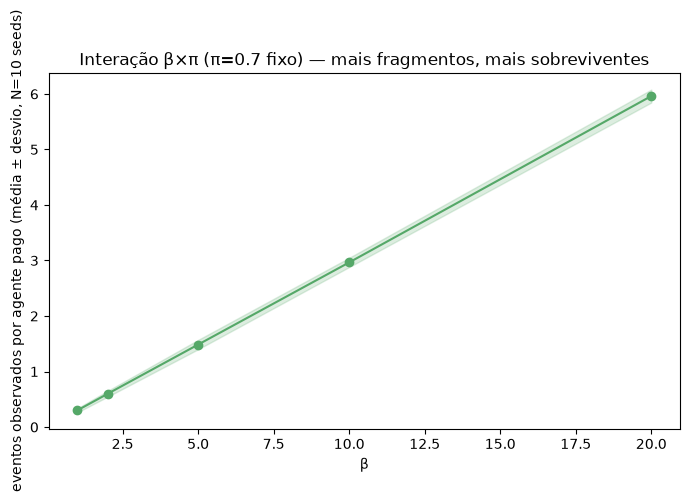

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
medias_beta = np.array(medias_beta)
desvios_beta = np.array(desvios_beta)

ax.plot(valores_beta, medias_beta, "o-", color="#55A868")
ax.fill_between(valores_beta, medias_beta - desvios_beta, medias_beta + desvios_beta, color="#55A868", alpha=0.2)

ax.set_xlabel("β")
ax.set_ylabel("eventos observados por agente pago (média ± desvio, N=10 seeds)")
ax.set_title(f"Interação β×π (π={PI_FIXO} fixo) — mais fragmentos, mais sobreviventes")
fig.tight_layout()
plt.show()

**Leitura:** a métrica cresce com β — cada agente pago gera β sub-eventos
brutos, e cada um sobrevive independentemente com probabilidade `1-π`;
quanto mais sub-eventos por agente, maior a chance esperada de que pelo
menos alguns sobrevivam (o valor esperado de sobreviventes por agente é
aproximadamente `β·(1-π)`, consistente com os números acima — ex. em
`π=0.7`, `1-π=0.3`, então `β=1 → ~0.3`, `β=20 → ~6.0`, batendo com a
tabela). Fragmentação (evasão do adversário) e privacidade (π) interagem:
mais fragmentação parcialmente compensa a ocultação de privacidade em
termos de quantos eventos aparecem observáveis, mesmo que cada evento
individual carregue menos valor monetário (`recompensa/β`, ver
`fonte_a_eventos_fronteira`).

## 4. Heatmap π × β

**Nota antes do heatmap:** esta figura é candidata a ir para o
artigo/TCC, mas `taxa_fonte_a`/`volume_medio_fonte_a` (Fonte A/B do modo
normal) e a ordem de grandeza geral do gerador ainda são suposições v0
não calibradas (ver `CLAUDE.md`) — a escala ABSOLUTA deste heatmap não
deve ser lida como realista ainda, só o padrão RELATIVO (direção do
gradiente π×β) é a informação confiável aqui.

In [8]:
valores_pi_heatmap = [0.0, 0.5, 0.75, 0.9, 0.95]
valores_beta_heatmap = [1, 2, 5, 10, 20]
N_SEEDS_HEATMAP = 10  # mesma contagem da Seção 3, por consistência

matriz = np.zeros((len(valores_pi_heatmap), len(valores_beta_heatmap)))

for i, pi in enumerate(valores_pi_heatmap):
    for j, beta in enumerate(valores_beta_heatmap):
        razoes = []
        for k in range(N_SEEDS_HEATMAP):
            modelo = ElectionModel(pi=pi, beta=beta, seed=300 + k, **kwargs_positiva)
            cenario = gerar_cenario_adversarial(modelo, tau_kendall=0.5, random_state_fonte_b=1, random_state_pi=400 + k)
            n_pagos = sum(1 for agente in modelo.agents if agente.aderiu)
            if n_pagos > 0:
                razoes.append(cenario.fonte_a["n_eventos"].sum() / n_pagos)
        matriz[i, j] = np.mean(razoes) if razoes else 0.0

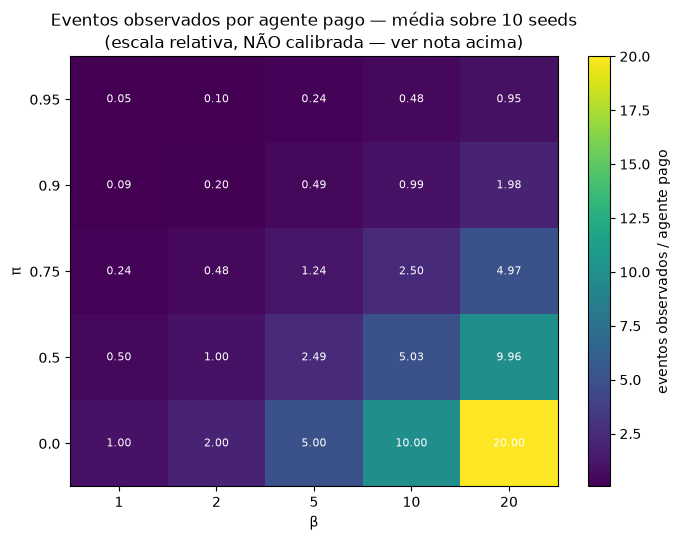

In [9]:
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(matriz, aspect="auto", origin="lower", cmap="viridis")

ax.set_xticks(range(len(valores_beta_heatmap)))
ax.set_xticklabels(valores_beta_heatmap)
ax.set_yticks(range(len(valores_pi_heatmap)))
ax.set_yticklabels(valores_pi_heatmap)
ax.set_xlabel("β")
ax.set_ylabel("π")
ax.set_title("Eventos observados por agente pago — média sobre 10 seeds\n(escala relativa, NÃO calibrada — ver nota acima)")

for i in range(len(valores_pi_heatmap)):
    for j in range(len(valores_beta_heatmap)):
        ax.text(j, i, f"{matriz[i, j]:.2f}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(im, ax=ax, label="eventos observados / agente pago")
fig.tight_layout()
plt.show()

**Leitura:** o gradiente cresce da esquerda para a direita (β crescente)
e de baixo para cima é dominado por π decrescente (menos privacidade =
mais observável) — os dois eixos do design fatorial interagem de forma
consistente com as Seções 1 e 3 isoladas. Reforça: os valores absolutos
dependem de `taxa_fonte_a`/`volume_medio_fonte_a`/`n_agentes` (stubs v0,
não calibrados) — só o padrão relativo do gradiente é a leitura confiável
desta figura por enquanto.